# Monte Carlo Uncertainty Analysis

One historical test period cannot show every outcome that might occur. This notebook uses validation forecast errors to create alternative demand paths and compare the same simple policies used in notebook 09.


In [1]:
from collections import deque

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox

validation_risk = pd.read_parquet(
    "data/processed/validation_inventory_risk_daily.parquet"
)
test_risk = pd.read_parquet(
    "data/processed/inventory_risk_daily.parquet"
)
empirical_buffers = pd.read_parquet(
    "data/processed/empirical_inventory_buffers.parquet"
)

RANDOM_SEED = 42
BLOCK_LENGTH = 7
N_SAMPLES = 2000
LEAD_TIME = 14
POLICIES = ["none", "p90", "p95", "p98"]
rng = np.random.default_rng(RANDOM_SEED)


## Forecast Error Dependence

Forecast errors can occur in clusters. ACF and Ljung-Box results check whether resampling individual days would ignore meaningful dependence.


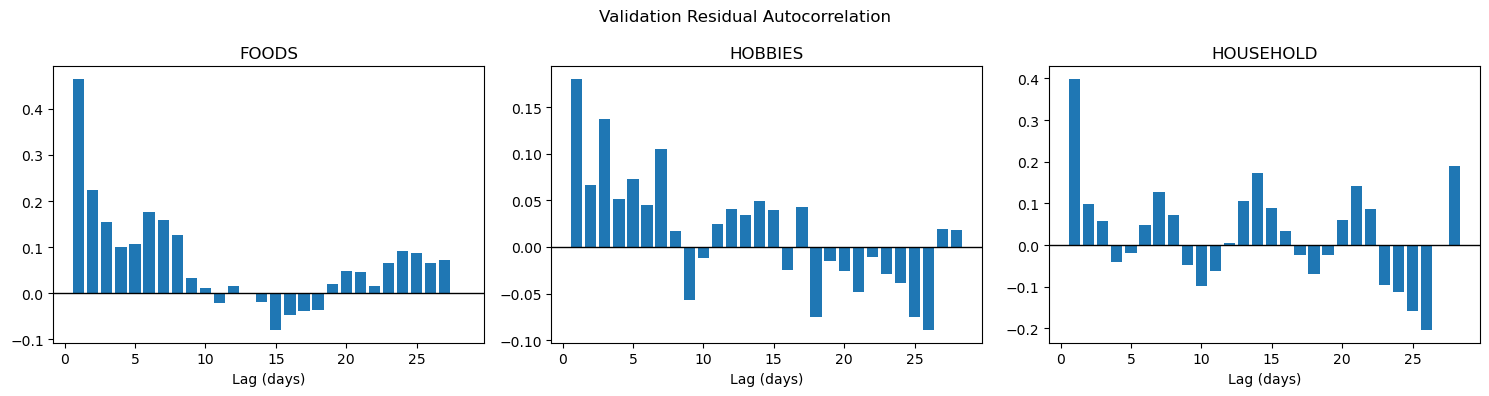

,cat_id,lag1_acf,lag7_acf,ljung_box_lag7_pvalue,ljung_box_lag14_pvalue
0,FOODS,0.465,0.159,0.0,0.000
1,HOBBIES,0.180,0.105,0.0,0.004
2,HOUSEHOLD,0.399,0.128,0.0,0.000


In [2]:
dependence_rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, category in zip(axes, ["FOODS", "HOBBIES", "HOUSEHOLD"]):
    residuals = validation_risk.loc[
        validation_risk["cat_id"] == category, "residual"
    ].to_numpy()
    acf_values = acf(residuals, nlags=28, fft=True)
    ljung_box = acorr_ljungbox(
        residuals, lags=[7, 14, 28], return_df=True
    )

    dependence_rows.append(
        {
            "cat_id": category,
            "lag1_acf": acf_values[1],
            "lag7_acf": acf_values[7],
            "ljung_box_lag7_pvalue": ljung_box.loc[7, "lb_pvalue"],
            "ljung_box_lag14_pvalue": ljung_box.loc[14, "lb_pvalue"],
        }
    )
    ax.bar(range(1, 29), acf_values[1:])
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(category)
    ax.set_xlabel("Lag (days)")

fig.suptitle("Validation Residual Autocorrelation")
plt.tight_layout()
plt.show()

dependence_summary = pd.DataFrame(dependence_rows).round(3)
dependence_summary


## Bootstrap Uncertainty

Because daily errors are dependent, individual days are not sampled independently. Seven-day blocks retain some weekly clustering while keeping the method easy to reproduce.


In [3]:
def moving_block_bootstrap(values, n_samples, block_length, sample_length, rng):
    values = np.asarray(values, dtype=float)
    blocks_needed = int(np.ceil(sample_length / block_length))
    max_start = len(values) - block_length
    samples = np.empty((n_samples, sample_length))

    for sample_id in range(n_samples):
        starts = rng.integers(0, max_start + 1, size=blocks_needed)
        samples[sample_id] = np.concatenate(
            [values[start:start + block_length] for start in starts]
        )[:sample_length]

    return samples


In [4]:
bootstrap_rows = []
residual_paths = {}

for category in ["FOODS", "HOBBIES", "HOUSEHOLD"]:
    residuals = validation_risk.loc[
        validation_risk["cat_id"] == category, "residual"
    ].to_numpy()
    paths = moving_block_bootstrap(
        residuals,
        N_SAMPLES,
        BLOCK_LENGTH,
        len(residuals),
        rng,
    )
    residual_paths[category] = paths
    means = paths.mean(axis=1)

    bootstrap_rows.append(
        {
            "cat_id": category,
            "mean_residual": residuals.mean(),
            "bootstrap_se": means.std(ddof=1),
            "ci_lower": np.quantile(means, 0.025),
            "ci_upper": np.quantile(means, 0.975),
        }
    )

bootstrap_summary = pd.DataFrame(bootstrap_rows).round(2)
bootstrap_summary


,cat_id,mean_residual,bootstrap_se,ci_lower,ci_upper
0,FOODS,564.04,197.86,181.18,941.31
1,HOBBIES,39.67,20.16,3.72,81.20
2,HOUSEHOLD,260.60,53.82,163.62,376.00


## Simulated Demand Paths

Each path adds a block-resampled validation residual sequence to the fixed final-test forecast. Demand is clipped at zero. The random seed is fixed so results are reproducible.


In [5]:
def simulate_inventory(forecasts, demand, lead_time, safety_stock):
    pipeline = deque([0.0] * lead_time)
    on_order = 0.0
    on_hand = forecasts[:lead_time].sum() + safety_stock
    lost_units = 0.0
    stockout_days = 0
    inventory_total = 0.0

    for day in range(len(forecasts)):
        receipts = pipeline.popleft()
        on_order -= receipts
        available = on_hand + receipts

        fulfilled = min(available, demand[day])
        lost = demand[day] - fulfilled
        ending_inventory = available - fulfilled
        inventory_position = ending_inventory + on_order

        forecast_end = min(day + lead_time + 1, len(forecasts))
        future_forecast = forecasts[day + 1:forecast_end].sum()
        missing_days = lead_time - (forecast_end - day - 1)
        if missing_days > 0:
            future_forecast += missing_days * forecasts[-1]

        order_quantity = max(
            0.0,
            future_forecast + safety_stock - inventory_position,
        )
        pipeline.append(order_quantity)
        on_order += order_quantity
        on_hand = ending_inventory

        lost_units += lost
        stockout_days += int(lost > 0)
        inventory_total += ending_inventory

    assert on_hand >= -1e-8
    total_demand = demand.sum()
    return {
        "fill_rate": 1 - lost_units / total_demand,
        "total_lost_units": lost_units,
        "stockout_days": stockout_days,
        "avg_on_hand_inventory": inventory_total / len(forecasts),
    }


In [6]:
buffer_lookup = empirical_buffers.set_index(
    ["cat_id", "lead_time_days"]
)
simulation_rows = []

for category in ["FOODS", "HOBBIES", "HOUSEHOLD"]:
    category_data = (
        test_risk[test_risk["cat_id"] == category]
        .sort_values("ds")
    )
    forecasts = category_data["forecast"].to_numpy(float)
    paths = residual_paths[category]

    for simulation_id in range(N_SAMPLES):
        demand = np.clip(forecasts + paths[simulation_id], 0, None)
        assert (demand >= 0).all()

        for policy in POLICIES:
            safety_stock = 0.0 if policy == "none" else buffer_lookup.loc[
                (category, LEAD_TIME), f"buffer_{policy[1:]}"
            ]
            metrics = simulate_inventory(
                forecasts, demand, LEAD_TIME, safety_stock
            )
            simulation_rows.append(
                {
                    "cat_id": category,
                    "policy": policy,
                    "simulation_id": simulation_id,
                    "safety_stock": safety_stock,
                    **metrics,
                }
            )

simulation_results = pd.DataFrame(simulation_rows)
print("Simulation rows:", len(simulation_results))


Simulation rows: 24000


## Policy Results


In [7]:
policy_summary = (
    simulation_results
    .groupby(["cat_id", "policy"], observed=True)
    .agg(
        mean_fill_rate=("fill_rate", "mean"),
        p05_fill_rate=("fill_rate", lambda x: x.quantile(0.05)),
        p95_fill_rate=("fill_rate", lambda x: x.quantile(0.95)),
        mean_lost_units=("total_lost_units", "mean"),
        p95_lost_units=("total_lost_units", lambda x: x.quantile(0.95)),
        mean_inventory=("avg_on_hand_inventory", "mean"),
    )
    .reset_index()
)

policy_summary.round(4)


,cat_id,policy,mean_fill_rate,p05_fill_rate,p95_fill_rate,mean_lost_units,p95_lost_units,mean_inventory
0,FOODS,none,0.9662,0.9568,0.9755,322192.4965,415911.4273,10513.1556
1,FOODS,p90,0.9981,0.9950,1.0000,18550.9166,48140.3950,32569.5868
2,FOODS,p95,0.9995,0.9980,1.0000,4336.7342,19405.3658,42088.7024
3,FOODS,p98,0.9998,0.9988,1.0000,1706.6726,11490.0983,47448.6918
4,HOBBIES,none,0.9767,0.9707,0.9828,31887.2544,40372.0971,1567.6997
5,HOBBIES,p90,0.9982,0.9962,0.9997,2408.1527,5144.2377,3256.0003
6,HOBBIES,p95,0.9992,0.9980,1.0000,1051.3100,2801.4273,3685.1077
7,HOBBIES,p98,0.9997,0.9989,1.0000,384.3977,1442.9225,4119.3814
8,HOUSEHOLD,none,0.9670,0.9603,0.9731,125835.8741,152842.4640,3463.3520
9,HOUSEHOLD,p90,0.9964,0.9936,0.9987,13757.5798,24531.2062,7618.3292


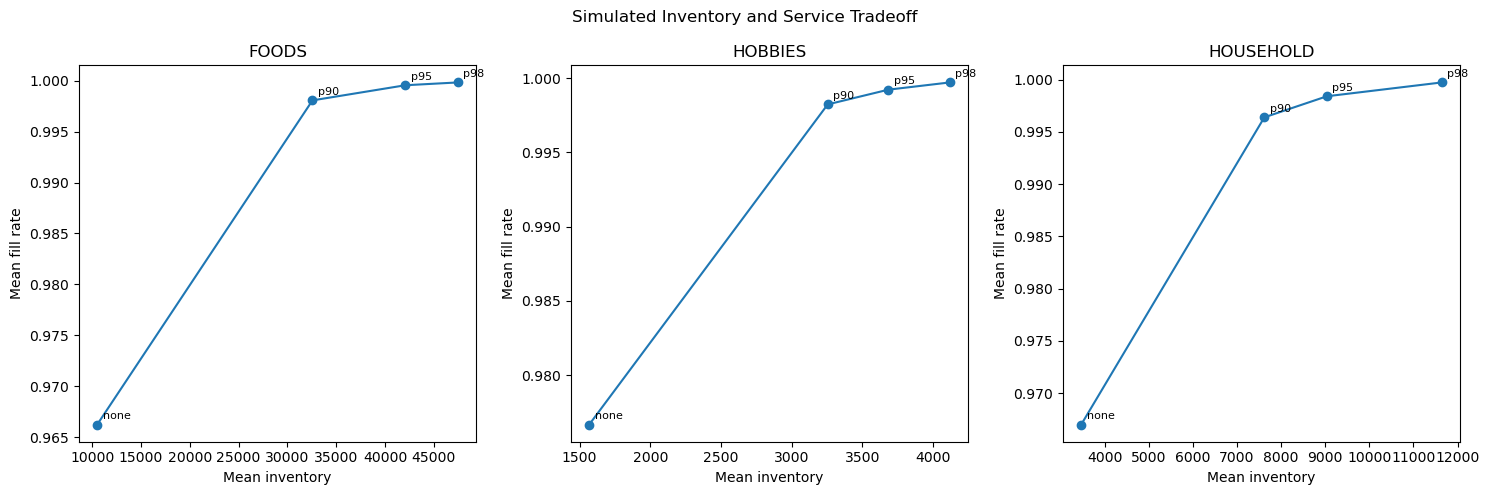

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, category in zip(axes, ["FOODS", "HOBBIES", "HOUSEHOLD"]):
    plot_data = policy_summary[
        policy_summary["cat_id"] == category
    ].set_index("policy").loc[POLICIES].reset_index()

    ax.plot(
        plot_data["mean_inventory"],
        plot_data["mean_fill_rate"],
        marker="o",
    )
    for _, row in plot_data.iterrows():
        ax.annotate(
            row["policy"],
            (row["mean_inventory"], row["mean_fill_rate"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )
    ax.set_title(category)
    ax.set_xlabel("Mean inventory")
    ax.set_ylabel("Mean fill rate")

fig.suptitle("Simulated Inventory and Service Tradeoff")
plt.tight_layout()
plt.show()


## Comparing Safety Buffers

Policies use the same simulated demand paths, so p90→p95 and p95→p98 differences are paired. Bootstrap intervals summarize uncertainty in each mean difference.


In [9]:
comparison_rows = []

for category in ["FOODS", "HOBBIES", "HOUSEHOLD"]:
    category_results = simulation_results[
        simulation_results["cat_id"] == category
    ]

    for policy_a, policy_b in [("p90", "p95"), ("p95", "p98")]:
        left = category_results[
            category_results["policy"] == policy_a
        ].set_index("simulation_id")
        right = category_results[
            category_results["policy"] == policy_b
        ].set_index("simulation_id")

        fill_difference = (
            right["fill_rate"] - left["fill_rate"]
        ).to_numpy()
        inventory_difference = (
            right["avg_on_hand_inventory"]
            - left["avg_on_hand_inventory"]
        ).to_numpy()

        sample_index = rng.integers(
            0, len(fill_difference), size=(N_SAMPLES, len(fill_difference))
        )
        boot_means = fill_difference[sample_index].mean(axis=1)

        comparison_rows.append(
            {
                "cat_id": category,
                "comparison": f"{policy_a} to {policy_b}",
                "mean_fill_gain": fill_difference.mean(),
                "ci_lower": np.quantile(boot_means, 0.025),
                "ci_upper": np.quantile(boot_means, 0.975),
                "probability_fill_improves": (fill_difference > 0).mean(),
                "mean_inventory_increase": inventory_difference.mean(),
            }
        )

policy_comparisons = pd.DataFrame(comparison_rows)
policy_comparisons.round(5)


,cat_id,comparison,mean_fill_gain,ci_lower,ci_upper,probability_fill_improves,mean_inventory_increase
0,FOODS,p90 to p95,0.00149,0.00144,0.00153,0.931,9519.11558
1,FOODS,p95 to p98,0.00027,0.00026,0.00029,0.518,5359.98940
2,HOBBIES,p90 to p95,0.00099,0.00097,0.00101,0.990,429.10745
3,HOBBIES,p95 to p98,0.00049,0.00047,0.00050,0.892,434.27370
4,HOUSEHOLD,p90 to p95,0.00202,0.00199,0.00205,1.000,1419.46784
5,HOUSEHOLD,p95 to p98,0.00132,0.00129,0.00136,0.971,2604.22145


## Tail Risk

CVaR / Expected Shortfall is the average lost-unit exposure in the worst 5% of simulated paths.


In [10]:
tail_rows = []

for (category, policy), group in simulation_results.groupby(
    ["cat_id", "policy"], observed=True
):
    threshold = group["total_lost_units"].quantile(0.95)
    worst_paths = group.loc[
        group["total_lost_units"] >= threshold,
        "total_lost_units",
    ]
    tail_rows.append(
        {
            "cat_id": category,
            "policy": policy,
            "p95_lost_units": threshold,
            "cvar_95_lost_units": worst_paths.mean(),
        }
    )

tail_risk = pd.DataFrame(tail_rows)
tail_risk.round(1)


,cat_id,policy,p95_lost_units,cvar_95_lost_units
0,FOODS,none,415911.4,444039.8
1,FOODS,p90,48140.4,57420.7
2,FOODS,p95,19405.4,25838.5
3,FOODS,p98,11490.1,16186.1
4,HOBBIES,none,40372.1,42941.0
5,HOBBIES,p90,5144.2,5961.1
6,HOBBIES,p95,2801.4,3467.3
7,HOBBIES,p98,1442.9,1946.1
8,HOUSEHOLD,none,152842.5,159488.1
9,HOUSEHOLD,p90,24531.2,27870.0


## Findings

- Validation errors are serially dependent, so 7-day block sampling is more appropriate than sampling individual days.
- Historical buffers improve average simulated service, but larger buffers require more inventory.
- The gain from p90 to p95 is generally larger than the gain from p95 to p98.
- CVaR shows that larger buffers can still reduce severe lost-unit outcomes even when average fill-rate gains are small.

Results remain conditional on historical residuals and hypothetical inventory assumptions. No policy is labeled optimal because true costs and service targets are unavailable.


In [11]:
bootstrap_summary = bootstrap_summary.merge(
    dependence_summary,
    on="cat_id",
    how="left",
)
policy_summary_with_tail = policy_summary.merge(
    tail_risk[["cat_id", "policy", "cvar_95_lost_units"]],
    on=["cat_id", "policy"],
    how="left",
)

bootstrap_summary.to_parquet(
    "data/processed/bootstrap_inference_summary.parquet", index=False
)
simulation_results.to_parquet(
    "data/processed/monte_carlo_policy_results.parquet", index=False
)
policy_summary_with_tail.to_parquet(
    "data/processed/monte_carlo_policy_summary.parquet", index=False
)
policy_comparisons.to_parquet(
    "data/processed/monte_carlo_policy_comparisons.parquet", index=False
)

print("Saved bootstrap, simulation, policy, and comparison results.")


Saved bootstrap, simulation, policy, and comparison results.
